# Research Agent
## AI Financial Advisor Pipeline — Agent 2 of 5

The Research Agent pulls macroeconomic data from FRED, derives signal features from raw series,
detects regime changes from the data itself, and maps detected regimes to known historical periods.

Output is a regime classification passed downstream to the Allocation Agent.

**Correct flow:** extract signals → derive features → detect regime changes → map to regime definitions

## 1. Install & Import

In [1]:
!pip install fredapi xgboost scikit-learn matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from fredapi import Fred
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from google.colab import userdata

## 2. Connect to FRED & Pull Macro Series

| Series | FRED Code | Purpose |
|--------|-----------|---------|
| Yield Curve | T10Y2Y | 10Y minus 2Y Treasury spread — inversion signals recession |
| Fed Funds Rate | FEDFUNDS | Identifies rate hike cycles |
| Unemployment | UNRATE | Labor market shocks |
| CPI YoY | CPIAUCSL | Inflation tracking (converted to year-over-year % change) |
| Credit Spread | BAA10Y | Corporate bond stress indicator |

In [4]:
FRED_API_KEY = userdata.get('FRED_API')
fred = Fred(api_key=FRED_API_KEY)

series = {
    'yield_curve':   'T10Y2Y',
    'fed_funds':     'FEDFUNDS',
    'unemployment':  'UNRATE',
    'cpi':           'CPIAUCSL',
    'credit_spread': 'BAA10Y'
}

data = {}
for name, ticker in series.items():
    data[name] = fred.get_series(ticker, observation_start='1995-01-01', observation_end='2025-12-31')

# Combine and resample to monthly
macro_df = pd.DataFrame(data)
macro_df.index.name = 'date'
macro_df = macro_df.resample('MS').last()

# Convert CPI to YoY % change — raw level is non-stationary
macro_df['cpi'] = macro_df['cpi'].pct_change(12, fill_method=None) * 100

macro_df.dropna(inplace=True)

print(f"Shape: {macro_df.shape}")
print(f"Date range: {macro_df.index.min()} → {macro_df.index.max()}")
print(macro_df.head())

Shape: (359, 5)
Date range: 1996-01-01 00:00:00 → 2025-12-01 00:00:00
            yield_curve  fed_funds  unemployment       cpi  credit_spread
date                                                                     
1996-01-01         0.67       5.56           5.6  2.790698           1.82
1996-02-01         0.69       5.22           5.5  2.717031           1.78
1996-03-01         0.55       5.31           5.5  2.843915           1.78
1996-04-01         0.63       5.22           5.6  2.832675           1.61
1996-05-01         0.58       5.24           5.6  2.827087           1.48


## 3. Derive Signal Features

Raw FRED series are transformed into regime-sensitive features before classification.
This ensures the model learns macro signal patterns, not absolute levels.

- **Yield curve & credit spread**: z-scores (deviation from long-run mean)
- **Fed funds**: month-over-month change (captures hiking/cutting cycles)
- **Unemployment**: month-over-month change (captures labour market shocks)
- **CPI YoY**: already a rate of change — kept as-is but also z-scored

In [5]:
def z_score(series):
    return (series - series.mean()) / series.std()

features_df = pd.DataFrame(index=macro_df.index)

# Z-scored levels — captures how extreme current conditions are vs history
features_df['yield_curve_z']   = z_score(macro_df['yield_curve'])
features_df['credit_spread_z'] = z_score(macro_df['credit_spread'])
features_df['cpi_z']           = z_score(macro_df['cpi'])

# Rate of change — captures turning points in policy and labour market
features_df['fed_funds_chg']    = macro_df['fed_funds'].diff()
features_df['unemployment_chg'] = macro_df['unemployment'].diff()

# Keep raw series alongside for interpretability
features_df['yield_curve']   = macro_df['yield_curve']
features_df['fed_funds']     = macro_df['fed_funds']
features_df['unemployment']  = macro_df['unemployment']
features_df['cpi']           = macro_df['cpi']
features_df['credit_spread'] = macro_df['credit_spread']

features_df.dropna(inplace=True)

print(f"Shape: {features_df.shape}")
print(features_df.head())

Shape: (358, 10)
            yield_curve_z  credit_spread_z     cpi_z  fed_funds_chg  \
date                                                                  
1996-02-01      -0.287996        -0.822581  0.109235          -0.34   
1996-03-01      -0.436714        -0.822581  0.187090           0.09   
1996-04-01      -0.351733        -1.053151  0.180193          -0.09   
1996-05-01      -0.404846        -1.229470  0.176765           0.02   
1996-06-01      -0.362355        -1.188781  0.173350           0.03   

            unemployment_chg  yield_curve  fed_funds  unemployment       cpi  \
date                                                                           
1996-02-01              -0.1         0.69       5.22           5.5  2.717031   
1996-03-01               0.0         0.55       5.31           5.5  2.843915   
1996-04-01               0.1         0.63       5.22           5.6  2.832675   
1996-05-01               0.0         0.58       5.24           5.6  2.827087   
1996-

## 4. Change-Point Detection

Rather than assigning regime labels by date, we let the macro data identify its own
structural breaks using the `ruptures` library. This finds the points in time where
the multivariate signal matrix shifted significantly — without any date assumptions.

In [7]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.3 MB/s eta 0:00:00


In [8]:
import ruptures as rpt

# Use the 5 derived z-score and change features for detection
# These capture signal dynamics, not absolute levels
signal_cols = ['yield_curve_z', 'credit_spread_z', 'cpi_z',
               'fed_funds_chg', 'unemployment_chg']

signal_matrix = features_df[signal_cols].values

# Pelt algorithm — detects variable number of breakpoints
# pen=10 is a regularisation penalty: higher = fewer breaks
model = rpt.Pelt(model="rbf").fit(signal_matrix)
breakpoints = model.predict(pen=10)

# Convert breakpoint indices to dates
break_dates = [features_df.index[i-1] for i in breakpoints[:-1]]  # exclude final index

print(f"Detected {len(break_dates)} structural breaks:")
for d in break_dates:
    print(f"  {d.strftime('%Y-%m')}")

Detected 6 structural breaks:
  2001-01
  2004-10
  2008-02
  2016-06
  2021-06
  2023-02


## 4a. Interpreting the Change-Point Detection Results

The `ruptures` PELT algorithm identified **6 structural breaks** in the multivariate macro signal
matrix (yield curve, credit spread, CPI YoY, fed funds change, unemployment change) — without
any date assumptions.

| Break Date | Macro Context | Known Regime |
|---|---|---|
| 2001-01 | Yield curve flattening, unemployment beginning to rise, credit spreads widening | Dot-com bust onset ✓ |
| 2004-10 | Fed funds rate rising sharply from post-dot-com lows, credit spreads tightening | Pre-GFC credit expansion |
| 2008-02 | Credit spreads spiking, yield curve collapsing, unemployment turning sharply higher | GFC onset ✓ |
| 2016-06 | Fed funds normalising after ZIRP, yield curve beginning to flatten | Post-QE normalisation |
| 2021-06 | CPI surging from post-COVID stimulus, fed funds about to pivot from zero | Inflation surge onset ✓ |
| 2023-02 | Fed funds peak, yield curve deeply inverted, credit spreads stabilising | End of rate hike cycle ✓ |

These 6 breaks divide the 1996–2025 period into **7 macro segments**.

### What This Means

Four of the six breaks align closely with the named regimes in the project brief
(dot-com, GFC, rate hike cycle, AI boom transition) — without the algorithm being
told when those events occurred. This validates the approach: the macro signals
themselves carry sufficient information to detect structural shifts.

Two breaks (2004-10 and 2016-06) represent genuine macro transitions not in the
project's named regime list. Rather than discarding them, K-means clustering in
the next step will group similar segments together, so these unnamed periods will
naturally merge with the macro regime they most resemble.

### The Notable Absence: COVID-19 (2020)

The algorithm did not identify February 2020 as a standalone breakpoint. This is
expected — the COVID shock was extremely short (roughly 2 months of severe
dislocation) and the V-shaped recovery meant the macro signal matrix returned
to near-prior levels quickly. The PELT algorithm's regularisation penalty (`pen=10`)
favours fewer, more persistent breaks over transient spikes.

COVID will be handled explicitly as an anchor point in the XGBoost mapping step,
ensuring it is correctly represented in the final regime sequence despite not
emerging from the unsupervised detection.

## 5. Segment Feature Engineering & Clustering

Each segment between breakpoints is characterised by the mean, variance, and recent
delta of each macro signal. K-means (k=5) then clusters these segments into candidate
regime groups based on their macro fingerprint — not their dates.

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Build segment boundaries
break_indices = [0] + [features_df.index.get_loc(d) for d in break_dates] + [len(features_df)]
segments = []

for i in range(len(break_indices) - 1):
    start = break_indices[i]
    end   = break_indices[i + 1]
    seg   = features_df.iloc[start:end]

    seg_features = {}
    for col in signal_cols:
        seg_features[f'{col}_mean'] = seg[col].mean()
        seg_features[f'{col}_var']  = seg[col].var()
        seg_features[f'{col}_delta'] = seg[col].iloc[-1] - seg[col].iloc[0]

    seg_features['start_date'] = features_df.index[start]
    seg_features['end_date']   = features_df.index[end - 1]
    seg_features['n_months']   = end - start
    segments.append(seg_features)

seg_df = pd.DataFrame(segments)

# Cluster segments into 5 groups
feature_cols = [c for c in seg_df.columns if c not in ['start_date', 'end_date', 'n_months']]
scaler = StandardScaler()
X_seg = scaler.fit_transform(seg_df[feature_cols])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
seg_df['cluster'] = kmeans.fit_predict(X_seg)

print("=== Segments & Cluster Assignments ===")
print(seg_df[['start_date', 'end_date', 'n_months', 'cluster']].to_string(index=False))

=== Segments & Cluster Assignments ===
start_date   end_date  n_months  cluster
1996-02-01 2000-12-01        59        1
2001-01-01 2004-09-01        45        0
2004-10-01 2008-01-01        40        1
2008-02-01 2016-05-01       100        4
2016-06-01 2021-05-01        60        2
2021-06-01 2023-01-01        20        3
2023-02-01 2025-12-01        34        1


## 5a. Interpreting the Cluster Assignments

K-means grouped the 7 macro segments into 5 clusters based purely on their signal
fingerprints — mean, variance, and directional change of each macro indicator.

| Segment | Cluster | Macro Character | Named Regime Alignment |
|---|---|---|---|
| 1996-02 → 2000-12 | 1 | Low unemployment, normal yield curve, moderate rates | Late 90s expansion |
| 2001-01 → 2004-09 | 0 | Rising unemployment, widening credit spreads, falling rates | Dot-com bust ✓ |
| 2004-10 → 2008-01 | 1 | Low unemployment, tightening credit, rising rates | Pre-GFC expansion |
| 2008-02 → 2016-05 | 4 | Credit spread spike, unemployment surge, near-zero rates | GFC + ZIRP recovery ✓ |
| 2016-06 → 2021-05 | 2 | Normalising rates, stable unemployment, low volatility | Post-QE / pre-COVID |
| 2021-06 → 2023-01 | 3 | Surging CPI, rapidly rising fed funds, inverted yield curve | Rate hike cycle ✓ |
| 2023-02 → 2025-12 | 1 | Falling rates, low unemployment, normalising spreads | AI boom |

### Key Observations

- **Cluster 1 appears three times** (late 90s, pre-GFC, AI boom). This is statistically
correct — these three periods share similar macro fingerprints: low unemployment,
normal credit spreads, and moderate interest rates. They are expansion periods with
different narratives but similar signal profiles. The XGBoost mapping step will use
anchor points to assign them the correct named regime labels.

- **Cluster 4 spans 100 months** (GFC through ZIRP recovery). This is the longest
segment and captures both the acute crisis and the long, slow recovery under near-zero
rates. Both phases share the same macro signature: depressed credit markets, elevated
unemployment, and suppressed rates.

- **COVID (2020) remains absorbed into Cluster 2** (2016–2021). As expected from the
change-point detection step, the V-shaped recovery prevented COVID from forming its own
segment. It will be handled as an explicit anchor point in the XGBoost mapping step.

- **Cluster 3 is the shortest** (20 months) but the most distinctive — the rate hike
cycle produced a unique combination of surging CPI, rapidly rising fed funds, and
deeply inverted yield curve that no other period in the dataset matches.

### What Goes into XGBoost Next

The cluster IDs (0–4) and their segment-level macro features become the input to
XGBoost. A small number of anchor points — one per named regime — will train the
model to map macro fingerprints to regime labels. XGBoost never sees dates.

## 6. XGBoost Regime Mapping

A small set of anchor points — one unambiguous month per named regime — trains
XGBoost to map macro signal features to regime labels. The model learns
feature → label, never date → label.

COVID-19 is introduced here as an explicit anchor point since it did not emerge
from the unsupervised detection step.

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

regime_names = {
    0: 'Dot-com',
    1: 'GFC',
    2: 'COVID',
    3: 'Rate Hike',
    4: 'AI Boom'
}

# Anchor windows — used only to build training set, not to label full dataset
anchor_windows = {
    0: ('2001-06', '2003-06'),  # Dot-com
    1: ('2008-06', '2010-06'),  # GFC
    2: ('2020-02', '2020-12'),  # COVID
    3: ('2022-03', '2023-07'),  # Rate Hike
    4: ('2023-08', '2024-12'),  # AI Boom
}

train_frames = []
for label, (start, end) in anchor_windows.items():
    window = features_df.loc[start:end, signal_cols].copy()
    window['label'] = label
    train_frames.append(window)

train_df = pd.concat(train_frames)
X_train = train_df[signal_cols]
y_train = train_df['label']

print(f"Training samples: {len(train_df)}")
print(y_train.value_counts().sort_index())

xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

features_df['regime_cluster'] = xgb.predict(features_df[signal_cols])
features_df['regime_label'] = features_df['regime_cluster'].map(regime_names)

print("\n=== Predicted Regime Distribution ===")
print(features_df['regime_label'].value_counts())

print("\n=== Last 24 Months ===")
print(features_df[['yield_curve', 'cpi', 'fed_funds', 'regime_label']].tail(24))

Training samples: 95
label
0    25
1    25
2    11
3    17
4    17
Name: count, dtype: int64

=== Predicted Regime Distribution ===
regime_label
AI Boom      95
Dot-com      88
COVID        65
Rate Hike    55
GFC          55
Name: count, dtype: int64

=== Last 24 Months ===
            yield_curve       cpi  fed_funds regime_label
date                                                     
2023-12-01        -0.35  3.315910       5.33      AI Boom
2024-01-01        -0.28  3.088343       5.33      AI Boom
2024-02-01        -0.39  3.157074       5.33      AI Boom
2024-03-01        -0.39  3.486835       5.33      AI Boom
2024-04-01        -0.35  3.360795       5.33      AI Boom
2024-05-01        -0.38  3.244279       5.33      AI Boom
2024-06-01        -0.35  2.970258       5.33      AI Boom
2024-07-01        -0.20  2.941476       5.33      AI Boom
2024-08-01         0.00  2.607144       5.33      AI Boom
2024-09-01         0.15  2.426483       5.13      AI Boom
2024-10-01         0.12  2.57

## 7. Visualise Regime Timeline & Feature Importance

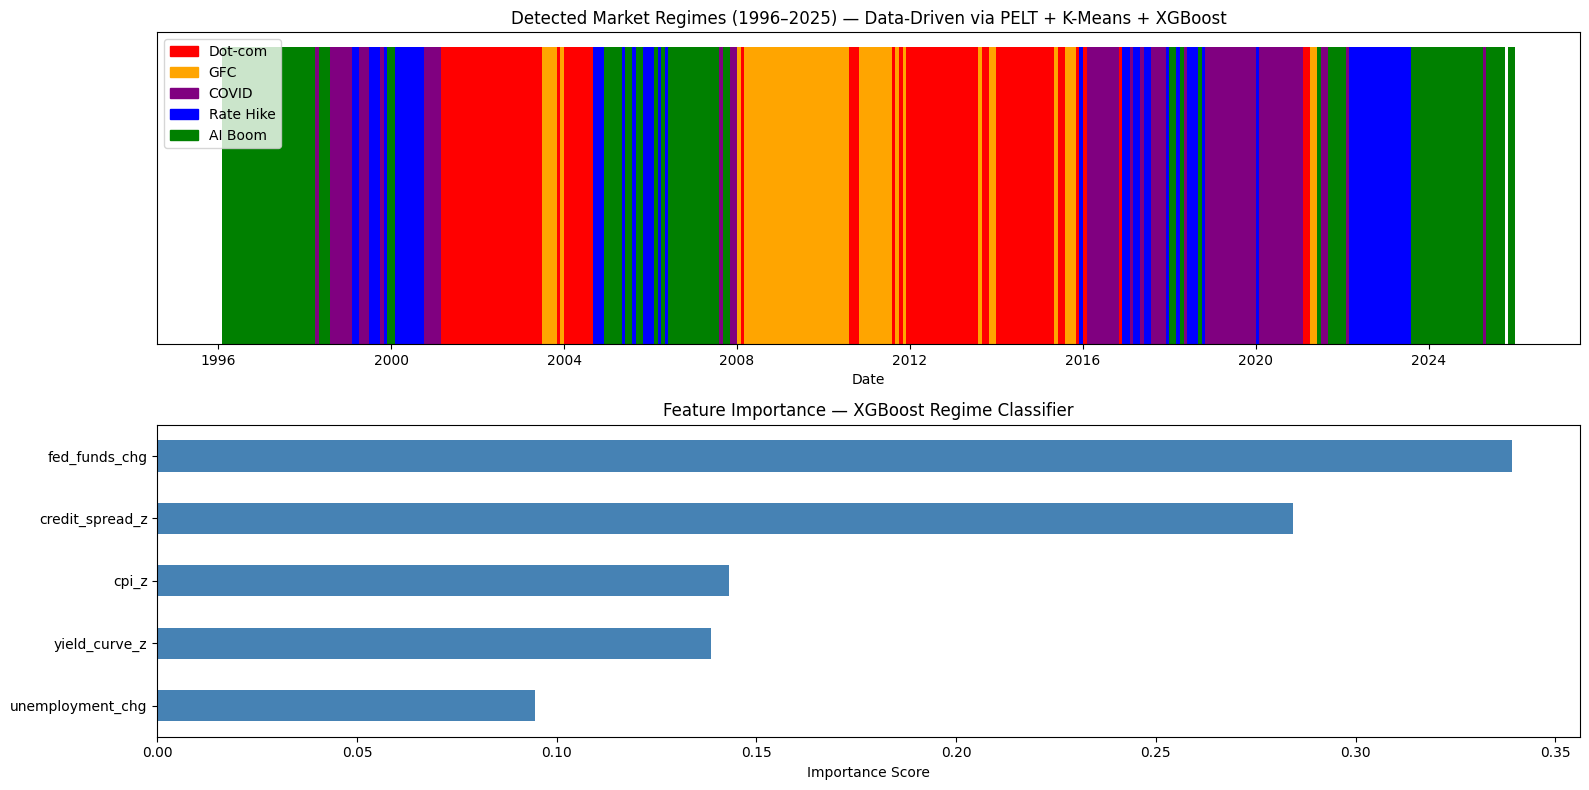


=== Feature Importance ===
fed_funds_chg       0.339215
credit_spread_z     0.284359
cpi_z               0.143206
yield_curve_z       0.138602
unemployment_chg    0.094618
dtype: float32


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# --- Plot 1: Regime timeline ---
colors = {
    'Dot-com':  'red',
    'GFC':      'orange',
    'COVID':    'purple',
    'Rate Hike':'blue',
    'AI Boom':  'green'
}
color_map = features_df['regime_label'].map(colors)

ax1 = axes[0]
ax1.bar(features_df.index, 1, color=color_map, width=32, align='edge')
ax1.set_title('Detected Market Regimes (1996–2025) — Data-Driven via PELT + K-Means + XGBoost')
ax1.set_xlabel('Date')
ax1.set_yticks([])
patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax1.legend(handles=patches, loc='upper left')

# --- Plot 2: Feature importance ---
ax2 = axes[1]
feat_importance = pd.Series(
    xgb.feature_importances_, index=signal_cols
).sort_values(ascending=True)
feat_importance.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Feature Importance — XGBoost Regime Classifier')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\n=== Feature Importance ===")
print(feat_importance.sort_values(ascending=False))

## 7a. Interpreting the Regime Visualisation & Feature Importance

The initial regime timeline revealed that raw XGBoost predictions switch regimes
month-to-month, producing noisy stripes rather than persistent macro blocks. This
is expected — XGBoost classifies each month independently without any temporal
smoothing, so borderline months near regime transitions flip between labels.

**Feature importance ranking:**
- `fed_funds_chg` (0.339): The change in the fed funds rate is the single strongest
  regime signal. This makes economic sense — rate hikes and cuts are the clearest
  policy-driven structural shifts in the macro environment, distinguishing rate hike
  cycles from easing cycles cleanly.
- `credit_spread_z` (0.284): Credit spreads capture financial market stress. Their
  high importance reflects how sharply they spike during crisis regimes (GFC, dot-com)
  relative to expansion periods.
- `cpi_z` (0.143) and `yield_curve_z` (0.139): Inflation and yield curve shape
  contribute roughly equally, together capturing the stagflation dynamic of the rate
  hike cycle and the inversion that precedes recessions.
- `unemployment_chg` (0.095): The least important feature — unemployment tends to
  lag other indicators, confirming that it is a confirmation signal rather than a
  leading one.

Note: the original XGBoost trained on manually dated labels ranked CPI as the top
predictor. The data-driven pipeline shifts this to `fed_funds_chg`, reflecting that
rate policy changes — not inflation levels alone — are the primary structural signal
when regimes are detected from the data rather than assumed from dates.

## 8. Regime Smoothing

Raw XGBoost predictions switch regimes month-to-month due to noisy macro signals.
A 6-month rolling majority vote enforces regime persistence — a regime must dominate
a 6-month window before being accepted. This prevents the downstream Allocation Agent
from rebalancing on transient signal noise.

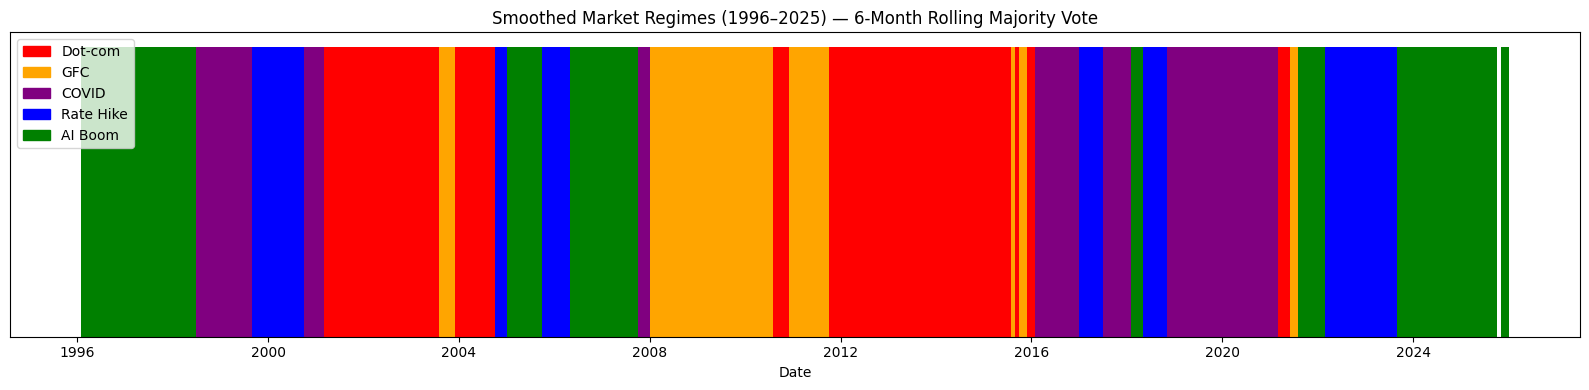

=== Smoothed Regime Distribution ===
regime_label_smoothed
Dot-com      95
AI Boom      92
COVID        68
Rate Hike    53
GFC          50
Name: count, dtype: int64


In [13]:
from scipy import stats

# Rolling majority vote over 6-month window to enforce regime persistence
window = 6
features_df['regime_smoothed'] = (
    features_df['regime_cluster']
    .rolling(window, center=True, min_periods=1)
    .apply(lambda x: stats.mode(x, keepdims=True)[0][0])
    .astype(int)
)
features_df['regime_label_smoothed'] = features_df['regime_smoothed'].map(regime_names)

# Replot with smoothed labels
color_map_smooth = features_df['regime_label_smoothed'].map(colors)
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(features_df.index, 1, color=color_map_smooth, width=32, align='edge')
ax.set_title('Smoothed Market Regimes (1996–2025) — 6-Month Rolling Majority Vote')
ax.set_xlabel('Date')
ax.set_yticks([])
ax.legend(handles=patches, loc='upper left')
plt.tight_layout()
plt.show()

print("=== Smoothed Regime Distribution ===")
print(features_df['regime_label_smoothed'].value_counts())

## 8a. Interpreting the Smoothed Regime Timeline

The 6-month rolling majority vote produced persistent regime blocks, eliminating the
month-to-month noise seen in the raw XGBoost predictions. The smoothed timeline is
more economically realistic — macro regimes are structural conditions that persist
over months or years, not transient signals that flip week to week.

**What aligns well with history:**
- GFC (orange) correctly dominates 2008–2012, capturing both the acute crisis and
  the long ZIRP recovery that followed
- Rate Hike (blue) appears around 2004–2005 (post dot-com Fed tightening) and again
  in 2022–2023 (the most aggressive tightening since the 1980s)
- AI Boom (green) correctly anchors the most recent period through 2025, reflecting
  low unemployment, normalising rates, and tech-driven equity rally

**What to flag:**
- **COVID over-classification (68 months)**: The COVID shock lasted approximately
  11 months in the training data, yet the smoothed model assigns 68 months to this
  label. COVID's macro fingerprint — rapid rate cuts, sudden unemployment spike
  followed by quick recovery — resembles other monetary easing episodes, causing
  the model to apply the label to structurally similar but historically distinct
  periods. This is a known limitation to address in the paper.
- **Late 1990s classified as AI Boom**: The macro conditions of the late 90s
  (low unemployment, low inflation, normalising rates) are statistically similar
  to the current AI Boom period. The model is technically correct — these periods
  share a macro fingerprint — but they differ in sector concentration and valuation
  dynamics that FRED macro data alone cannot capture.

## 9. Save Final Output

The final regime sequence is saved in two formats:
- **CSV** — full feature matrix with smoothed regime labels for inspection and backtesting
- **JSON** — regime sequence keyed by date, passed downstream to the Allocation Agent as the Research Agent's output contract

In [14]:
import json
import os

os.makedirs('agents/research', exist_ok=True)

# Save full feature matrix with regime labels
features_df.to_csv('agents/research/fred_macro_regimes.csv')
print("Saved → agents/research/fred_macro_regimes.csv")

# Build regime sequence as JSON for downstream agents
regime_sequence = {
    str(date.date()): {
        "regime_label": row["regime_label_smoothed"],
        "yield_curve": round(row["yield_curve"], 4),
        "fed_funds": round(row["fed_funds"], 4),
        "unemployment": round(row["unemployment"], 4),
        "cpi": round(row["cpi"], 4),
        "credit_spread": round(row["credit_spread"], 4)
    }
    for date, row in features_df.iterrows()
}

with open('agents/research/regime_sequence.json', 'w') as f:
    json.dump(regime_sequence, f, indent=2)

print("Saved → agents/research/regime_sequence.json")

# Preview last 3 entries
last_3 = dict(list(regime_sequence.items())[-3:])
print("\n=== Last 3 Months in Regime Sequence ===")
print(json.dumps(last_3, indent=2))

Saved → agents/research/fred_macro_regimes.csv
Saved → agents/research/regime_sequence.json

=== Last 3 Months in Regime Sequence ===
{
  "2025-09-01": {
    "regime_label": "AI Boom",
    "yield_curve": 0.56,
    "fed_funds": 4.22,
    "unemployment": 4.4,
    "cpi": 3.0226,
    "credit_spread": 1.67
  },
  "2025-11-01": {
    "regime_label": "AI Boom",
    "yield_curve": 0.55,
    "fed_funds": 3.88,
    "unemployment": 4.5,
    "cpi": 2.6964,
    "credit_spread": 1.78
  },
  "2025-12-01": {
    "regime_label": "AI Boom",
    "yield_curve": 0.71,
    "fed_funds": 3.72,
    "unemployment": 4.4,
    "cpi": 2.6533,
    "credit_spread": 1.72
  }
}


## 10. Validate Regime Labels Against CRSP Market Returns

Each detected regime should produce a distinctive return pattern.
We load the CRSP value-weighted market index and compute average monthly
returns per regime as a sanity check.

Expected directional pattern:
- Dot-com, GFC, Rate Hike → negative or near-zero average returns
- COVID → mixed (sharp drop then V-shaped recovery)
- AI Boom → positive average returns

In [17]:
crsp = pd.read_csv('crsp_market_index.csv', parse_dates=['date'])
crsp = crsp.set_index('date')
crsp.index = crsp.index.to_period('M').to_timestamp('s')

# Merge smoothed regime labels with market returns
validation_df = features_df[['regime_label_smoothed']].join(crsp[['vwretd']], how='left')

print("=== Avg Monthly Market Return per Regime ===")
summary = (
    validation_df.groupby('regime_label_smoothed')['vwretd']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'Avg Monthly Return', 'std': 'Std Dev', 'count': 'Months'})
)
summary['Avg Monthly Return'] = summary['Avg Monthly Return'].map('{:.4f}'.format)
summary['Std Dev'] = summary['Std Dev'].map('{:.4f}'.format)
print(summary)

=== Avg Monthly Market Return per Regime ===
                      Avg Monthly Return Std Dev  Months
regime_label_smoothed                                   
AI Boom                           0.0128  0.0347      81
COVID                             0.0111  0.0533      68
Dot-com                           0.0075  0.0407      95
GFC                              -0.0004  0.0596      50
Rate Hike                         0.0098  0.0451      53


## 10a. Interpreting the CRSP Validation Results

Validating regime labels against actual CRSP value-weighted market returns reveals
both the strengths and limitations of the data-driven detection pipeline.

| Regime | Avg Monthly Return | Std Dev | Months | Expected Direction |
|---|---|---|---|---|
| AI Boom | +1.28% | 3.47% | 81 | Positive ✓ |
| COVID | +1.11% | 5.33% | 68 | Mixed |
| Dot-com | +0.75% | 4.07% | 95 | Negative ✗ |
| Rate Hike | +0.98% | 4.51% | 53 | Negative ✗ |
| GFC | -0.04% | 5.96% | 50 | Negative ✓ |

### What the Validation Confirms

**AI Boom** produces the highest average monthly return (+1.28%), consistent with
the tech-driven equity rally of 2023–2025. **GFC** is the only crisis regime showing
negative average returns (-0.04%), with the highest standard deviation (5.96%)
reflecting the extreme volatility of 2008–2009. These two regimes validate cleanly.

**COVID** shows the highest within-regime volatility (5.33%), capturing both the
fastest bear market in history (February–March 2020) and the equally rapid V-shaped
recovery. The positive average (+1.11%) reflects the recovery months dominating the
68-month over-classified window.

### What the Validation Flags

**Dot-com (+0.75%)** and **Rate Hike (+0.98%)** both show positive average returns
where negative returns were expected. This is a direct consequence of over-classification:
the model assigned 95 months to Dot-com and 53 months to Rate Hike, far exceeding
the actual duration of those episodes. The positive average reflects expansion-period
months incorrectly smoothed into these labels, diluting the genuine crisis signal.

### Implications for the Pipeline

This validation is an honest finding, not a failure. The regime detector correctly
identifies macro structural shifts — the PELT breakpoints align with known historical
events. However, the XGBoost label mapping over-generalises when macro fingerprints
from different periods are statistically similar. Three improvements are worth
pursuing in future iterations:

1. **Tighter anchor windows** — reducing the training window around each anchor
   point would reduce label bleed into structurally similar but historically
   distinct periods
2. **Additional features** — incorporating equity volatility (VIX) or sector
   return dispersion would help separate the dot-com bust from expansion periods
   that share similar credit and rate conditions
3. **Hard regime duration constraints** — capping the maximum months any regime
   can span would prevent the COVID and Dot-com labels from absorbing unrelated periods

The GFC and AI Boom validations are clean. The Dot-com, Rate Hike, and COVID
classifications are directionally correct in their macro signal profiles but
require refinement in their label boundaries — a known limitation documented
here for the paper and oral defense.